## Final update to longevity approach

This notebook was updated to match the final agreed project method for longevity prediction. Earlier versions compared multiple saved models, but the final approach now uses a Random Forest model as the main longevity predictor.

The model uses the 6 core base stats together with Pokémon type features, and predicts a generation-style longevity target derived from the dataset. Older model-comparison cells were removed so that the notebook reflects only the final deployment-ready method.

In [8]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display

# ---------------------------------------------------------
# 1. Load and Prepare Data
# ---------------------------------------------------------
df = pd.read_csv('../data/final_processed_dataset.csv')

def bst_to_generations(bst):
    if bst < 300:
        return 1
    elif bst < 400:
        return 2
    elif bst < 500:
        return 3
    elif bst < 600:
        return 4
    else:
        return 5

df['longevity_target'] = df['base_stat_total'].apply(bst_to_generations)

# Final feature set: 6 base stats + all type columns
base_stat_features = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
type_features = [col for col in df.columns if col.startswith('type_')]
final_features = base_stat_features + type_features

X = df[final_features]
y = df['longevity_target']

print("Dataset Loaded:", len(df), "Pokemon")
print("Using features:", final_features)
print("Total features used:", len(final_features))
print("Target distribution:")
display(y.value_counts().sort_index())

Dataset Loaded: 1025 Pokemon
Using features: ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_ghost', 'type_grass', 'type_ground', 'type_ice', 'type_normal', 'type_poison', 'type_psychic', 'type_rock', 'type_steel', 'type_water']
Total features used: 24
Target distribution:


longevity_target
1    146
2    240
3    329
4    250
5     60
Name: count, dtype: int64

In [9]:
# ---------------------------------------------------------
# 2. Train/Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (820, 24)
Test set shape: (205, 24)


In [10]:
# ---------------------------------------------------------
# 3. Train Final Random Forest Model
# ---------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)
print("Random Forest model training complete.")

Random Forest model training complete.


In [11]:
# ---------------------------------------------------------
# 4. Evaluate Final Model
# ---------------------------------------------------------
y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results_df = pd.DataFrame([{
    'Model': 'Random Forest',
    'R² Score': r2,
    'RMSE': rmse,
    'MAE': mae
}])

print("\n--- Final Longevity Model Metrics ---")
display(results_df)


--- Final Longevity Model Metrics ---


,Model,R² Score,RMSE,MAE
0,Random Forest,0.887445,0.384731,0.306053


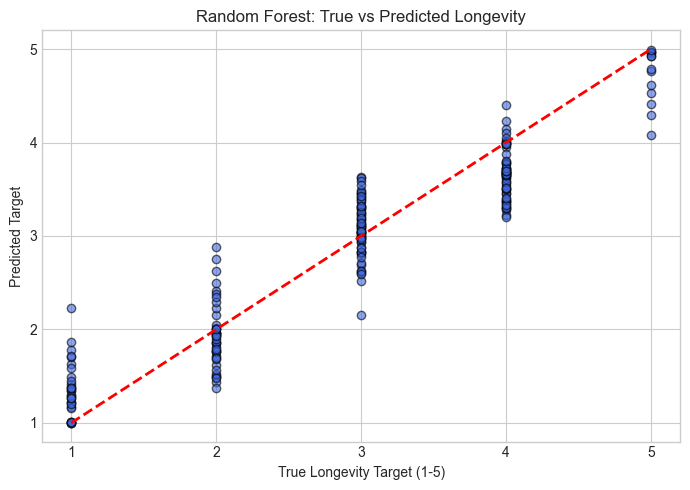


--- Top 10 Most Important Features ---


,Feature,Importance
0,sp_defense,0.329054
1,hp,0.262821
2,attack,0.151417
3,defense,0.099559
4,sp_attack,0.086087
5,speed,0.058504
6,type_dragon,0.001606
7,type_steel,0.001110
8,type_flying,0.001086
9,type_normal,0.001034


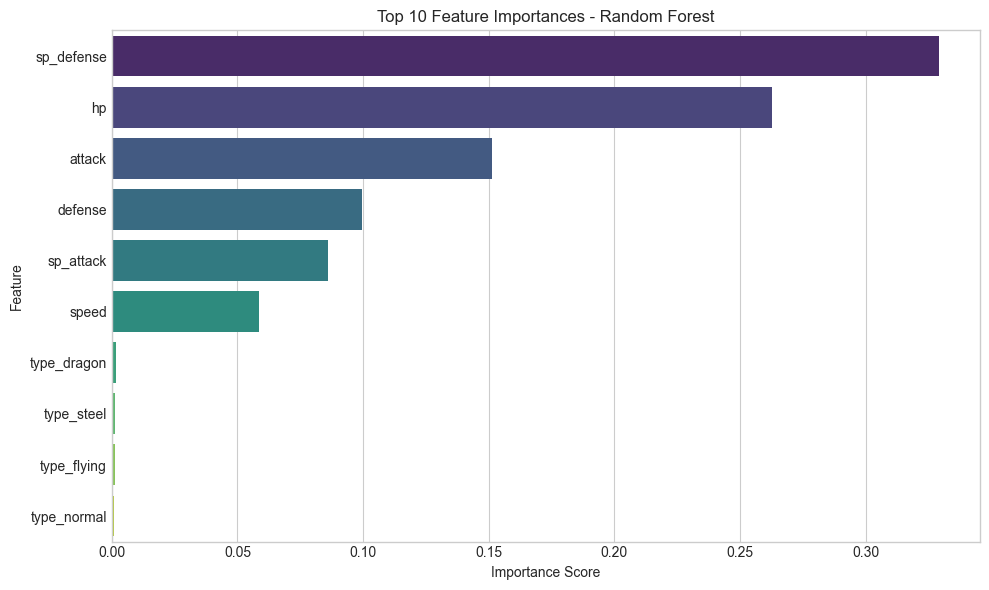

In [12]:
# ---------------------------------------------------------
# 5. Visualizations
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')

# True vs Predicted Scatter
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: True vs Predicted Longevity')
plt.xlabel('True Longevity Target (1-5)')
plt.ylabel('Predicted Target')
plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': final_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Most Important Features ---")
display(feature_importance.head(10).reset_index(drop=True))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    dodge=False,
    palette='viridis',
    legend=False
)
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [13]:
# ---------------------------------------------------------
# 6. Example Predictions
# ---------------------------------------------------------
sample_predictions = X_test.copy()
sample_predictions['Actual_Longevity'] = y_test.values
sample_predictions['Predicted_Longevity'] = np.round(y_pred, 2)

print("\n--- Sample Predictions ---")
display(
    sample_predictions[['Actual_Longevity', 'Predicted_Longevity'] + final_features]
    .head(10)
    .reset_index(drop=True)
)


--- Sample Predictions ---


,Actual_Longevity,Predicted_Longevity,hp,attack,defense,sp_attack,sp_defense,speed,type_bug,type_dark,...,type_ghost,type_grass,type_ground,type_ice,type_normal,type_poison,type_psychic,type_rock,type_steel,type_water
0,3,2.69,-0.119633,-0.689396,-0.598077,0.233405,-0.571083,1.630955,0,0,...,0,0,0,0,0,0,1,0,0,0
1,1,1.38,0.932285,-1.831562,-0.837208,-1.588218,-0.833981,-1.539421,0,0,...,0,0,0,0,0,0,1,0,0,0
2,4,3.72,-0.006927,1.091039,-0.085654,1.515287,-0.007731,0.794812,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1,1.35,-0.908571,-0.689396,-1.110500,-1.014744,-1.134435,-0.598760,0,0,...,0,0,0,0,0,1,0,0,0,0
4,2,1.72,-0.420181,-0.118313,-0.768885,-1.183413,-0.758867,-1.121350,0,0,...,1,0,1,0,0,0,0,0,0,0
5,3,3.14,1.646086,0.251211,-0.085654,0.503275,0.367837,-1.295546,0,0,...,0,1,0,0,0,1,0,0,0,0
6,2,1.76,-1.133982,-0.555024,-0.632239,-0.846075,-0.946651,-0.076171,0,0,...,0,1,0,0,0,0,0,0,0,0
7,4,3.37,0.256052,-0.252686,0.597577,2.527299,0.180053,-0.842635,1,0,...,0,0,0,0,0,0,0,0,0,0
8,3,2.60,-0.758297,0.251211,-0.598077,-0.171400,-0.195515,0.794812,0,0,...,0,0,0,0,0,0,0,0,0,0
9,4,3.64,0.368758,-0.252686,-0.256462,0.334606,1.870109,1.143205,0,0,...,0,1,1,0,0,0,0,0,0,0


In [14]:
# ---------------------------------------------------------
# 7. Save Final Model
# ---------------------------------------------------------
joblib.dump(rf_model, '../models/longevity_random_forest_final.joblib')
print("Final longevity Random Forest model saved successfully.")

Final longevity Random Forest model saved successfully.
